In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import joblib

# Tắt mấy cái cảnh báo vặt vãnh cho Jupyter nó sạch đẹp
import warnings
warnings.filterwarnings('ignore')

print("✅ Đã load xong thư viện!")

✅ Đã load xong thư viện!


In [2]:
np.random.seed(42)

# Nhãn 0: Bình thường (Tốc độ 40-50, Van 30-60 độ)
normal_rate = np.random.randint(40, 51, 600)
normal_valve = np.random.randint(30, 61, 600)
normal_label = np.zeros(600)

# Nhãn 1: Tắc kim (Tốc độ < 10, Van 40-90 độ)
block_rate = np.random.randint(0, 11, 200)
block_valve = np.random.randint(40, 90, 200)
block_label = np.ones(200)

# Nhãn 2: Chảy nhanh (Tốc độ 80-120, Van 70-90 độ)
fast_rate = np.random.randint(80, 120, 200)
fast_valve = np.random.randint(70, 90, 200)
fast_label = np.full(200, 2)

rates = np.concatenate([normal_rate, block_rate, fast_rate])
valves = np.concatenate([normal_valve, block_valve, fast_valve])
labels = np.concatenate([normal_label, block_label, fast_label])

df = pd.DataFrame({'current_rate': rates, 'valve_angle': valves, 'label': labels})

# In thử 5 dòng đầu và đếm số lượng từng loại
display(df.head())
print("\nSố lượng mẫu mỗi loại:")
print(df['label'].value_counts())

,current_rate,valve_angle,label
0,46,35,0.0
1,43,57,0.0
2,50,60,0.0
3,47,48,0.0
4,44,58,0.0



Số lượng mẫu mỗi loại:
label
0.0    600
1.0    200
2.0    200
Name: count, dtype: int64


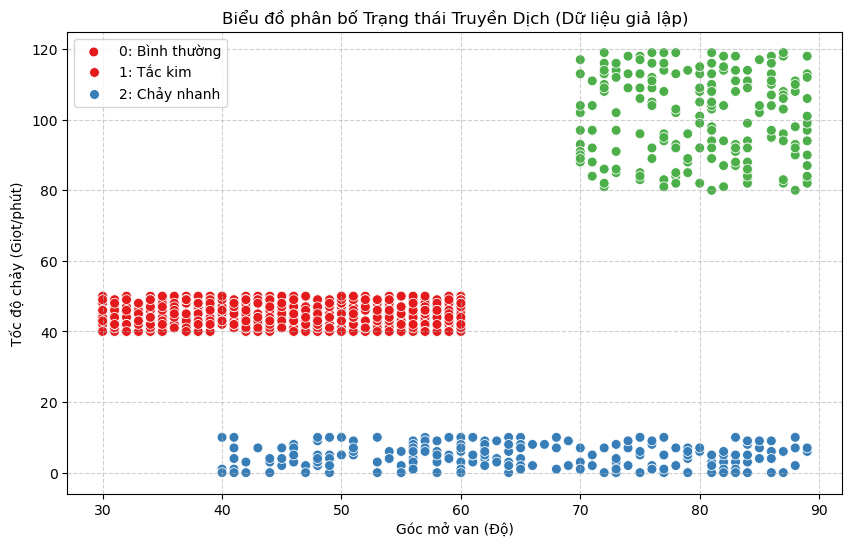

In [3]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='valve_angle', y='current_rate', hue='label', palette='Set1', s=50)
plt.title('Biểu đồ phân bố Trạng thái Truyền Dịch (Dữ liệu giả lập)')
plt.xlabel('Góc mở van (Độ)')
plt.ylabel('Tốc độ chảy (Giọt/phút)')
plt.legend(['0: Bình thường', '1: Tắc kim', '2: Chảy nhanh'])
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [4]:
# Chia 80% học, 20% thi
X = df[['current_rate', 'valve_angle']]
y = df['label']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Đang dạy AI...")
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)
print("✅ AI đã học xong!")

Đang dạy AI...
✅ AI đã học xong!


In [ ]:
y_pred = model.predict(X_test)

print("📊 BẢNG ĐIỂM CỦA AI:")
print(classification_report(y_test, y_pred, target_names=['Bình thường', 'Tắc kim', 'Chảy nhanh']))

# Vẽ Ma trận nhầm lẫn (Confusion Matrix) để xem AI có nhìn nhầm bệnh nào không
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues',
            xticklabels=['Bình thường', 'Tắc', 'Nhanh'],
            yticklabels=['Bình thường', 'Tắc', 'Nhanh'])
plt.title('Ma trận nhầm lẫn (Confusion Matrix)')
plt.xlabel('AI Dự đoán')
plt.ylabel('Thực tế')
plt.show()

# Lưu file model
model_filename = 'iv_drip_ai_model.pkl'
joblib.dump(model, model_filename)
print(f"📦 Đã đóng gói não AI thành file: {model_filename}")